In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("google.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    61 non-null     object 
 1   Open    61 non-null     float64
 2   High    61 non-null     float64
 3   Low     61 non-null     float64
 4   Close   61 non-null     float64
 5   Volume  61 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 3.0+ KB


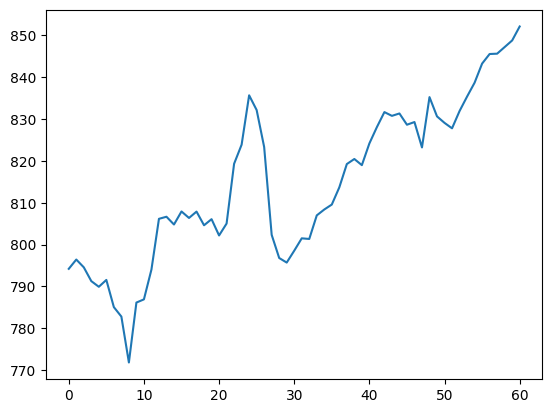

In [ ]:
df_req = df['Close']
plt.plot(df_req)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_req = scaler.fit_transform(np.array(df_req).reshape(-1,1))

In [ ]:
training_size = int(len(df_req)*0.8)
df_train = df_req[:training_size, :]
df_test = df_req[training_size:len(df_req), :]

In [ ]:
def create_dataset(data, step=4):
    X = []
    y = []
    for i in range(len(data)-step):
        X.append(data[i:i+step, :])
        y.append(data[i, :])

    return np.array(X), np.array(y)

x_train, y_train = create_dataset(df_train)
x_test, y_test = create_dataset(df_test)

In [ ]:
x_train

array([[[0.27870496],
        [0.30635093],
        [0.28318798],
        [0.24209223]],

       [[0.30635093],
        [0.28318798],
        [0.24209223],
        [0.22527981]],

       [[0.28318798],
        [0.24209223],
        [0.22527981],
        [0.24570341]],

       [[0.24209223],
        [0.22527981],
        [0.24570341],
        [0.16475695]],

       [[0.22527981],
        [0.24570341],
        [0.16475695],
        [0.13661236]],

       [[0.24570341],
        [0.16475695],
        [0.13661236],
        [0.        ]],

       [[0.16475695],
        [0.13661236],
        [0.        ],
        [0.17833138]],

       [[0.13661236],
        [0.        ],
        [0.17833138],
        [0.18779601]],

       [[0.        ],
        [0.17833138],
        [0.18779601],
        [0.27646347]],

       [[0.17833138],
        [0.18779601],
        [0.27646347],
        [0.42752207]],

       [[0.18779601],
        [0.27646347],
        [0.42752207],
        [0.43374872]],

       [[0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Sequential LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(32))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.2181
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1761
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1338
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0992
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0664
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0387
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0176
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0096
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0133
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0222
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0234
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0174
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0111
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0085
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0084
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━

In [ ]:
metrics = model.evaluate(x_test, y_test)
metrics

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 0.0013


0.0013055887538939714

In [ ]:
y_pred = scaler.inverse_transform(model.predict(x_test))
y_test = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step


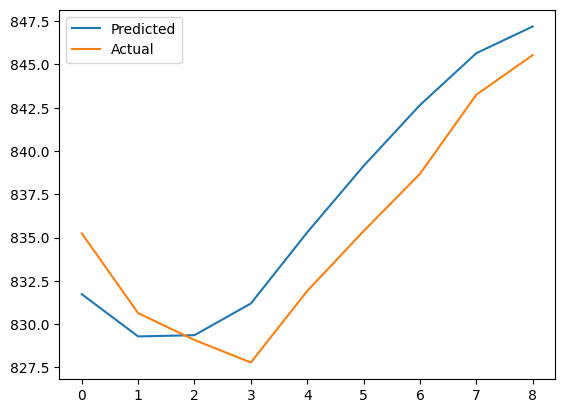

In [ ]:
plt.plot(y_pred, label="Predicted")
plt.plot(y_test, label="Actual")
plt.legend()

In [ ]:
print("\n========== MODEL SUMMARY ==========")
model.summary()

print("\n========== DATA SHAPES ==========")
print("X_train shape:", x_train.shape)
print("Y_train shape:", y_train.shape)
print("X_test shape :", x_test.shape)
print("Y_test shape :", y_test.shape)

print("\n========== MODEL INFO ==========")
print("Total layers:", len(model.layers))
print("Input features:", x_train.shape[2])
print("Output features:", y_train.shape[1])

print("\n========== HYPERPARAMETERS ==========")
print("Epochs:", 50)
print("Optimizer:", type(model.optimizer).__name__)
print("Learning rate:", model.optimizer.learning_rate.numpy())


========== MODEL SUMMARY ==========


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,605 (1021.90 KB)

 Trainable params: 87,201 (340.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 174,404 (681.27 KB)


========== DATA SHAPES ==========
X_train shape: (44, 4, 1)
Y_train shape: (44, 1)
X_test shape : (9, 4, 1)
Y_test shape : (9, 1)

========== MODEL INFO ==========
Total layers: 3
Input features: 1
Output features: 1

========== HYPERPARAMETERS ==========
Epochs: 50
Optimizer: Adam
Learning rate: 0.001


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----------- METRICS -----------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== ACCURACY METRICS ==========")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ----------- OPTIONAL: CUSTOM ACCURACY (NOT STANDARD) -----------
# Converts error into percentage-like accuracy
accuracy = 100 - (mae / np.mean(y_test)) * 100
print("Custom Accuracy (%):", accuracy)



========== ACCURACY METRICS ==========
MAE : 2.635755776909706
MSE : 8.418618263187822
RMSE: 2.9014855269650788
R2 Score: 0.7540225082246651
Custom Accuracy (%): 99.68444476000869


In [ ]:
print("Min price:", df['Close'].min())
print("Max price:", df['Close'].max())

Min price: 771.820007
Max price: 852.119995


In [ ]:
step = x_train.shape[1]   # safer

custom_input = [800, 820, 810, 830]

# 1. Convert to numpy + reshape for scaler
custom_input_array = np.array(custom_input).reshape(-1,1)

# 2. Scale
custom_input_scaled = scaler.transform(custom_input_array)

# 3. Reshape for LSTM → (1 sample, step timesteps, 1 feature)
custom_input_scaled = custom_input_scaled.reshape(1, step, 1)

# 4. Predict
prediction = model.predict(custom_input_scaled)

# 5. Convert back to original scale
prediction_actual = scaler.inverse_transform(prediction)

print("Predicted next price:", prediction_actual[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted next price: 809.4495
